In [ ]:
import sys
import os
sys.path.append("/media/aris/Data/master2025dev/DiffDA-Eval/")
from augmentation import DiffMixGenerator
from data.wrapper import get_dataset
import omegaconf


cfg_path = "/media/aris/Data/master2025dev/DiffDA-Eval/configs/generation/aris/GEN_diff_mix.yaml"
dataset_name = "100_real"
augmentation_ratio = 5
seed = 0
root_dir = "/media/aris/Data/master2025dev/aris_master/temp/"
resolution = 128

cfg = omegaconf.OmegaConf.load(cfg_path)
cfg.data.dataset = os.path.join(dataset_name, "real")
cfg.generation.root_dir = root_dir
cfg.generation.augmentation_ratio = augmentation_ratio
dset, _ = get_dataset(cfg, split="train", return_pure_image=True)

ti_embeds = cfg.generation.ti_embeds
list_files = os.listdir(ti_embeds)
file_name = [f for f in list_files if dataset_name in f and "seed" + str(seed) in f][0]
cfg.generation.ti_embeds = os.path.join(ti_embeds, file_name)

db_lora_weights = cfg.generation.db_lora_weights
list_files = os.listdir(db_lora_weights)
file_name = [f for f in list_files if dataset_name in f and "seed" + str(seed) in f][0]
cfg.generation.db_lora_weights = os.path.join(db_lora_weights, file_name)

from torchvision import transforms
# Create a compose to adjust the resolution of the images
transform = transforms.Compose([
    transforms.Resize((resolution, resolution)),
])

gen_images = DiffMixGenerator(cfg, dset)


Loaded ARIS dataset with 4 classes and 400 samples for split 'train'


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  6.23it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, 

Textual Inversion Weights /media/aris/Data/master2025dev/DiffDA-Eval/finetuned_generators/text_inversion/100_real_shot-1_seed0_04141307 loaded!
DreamBooth Weights /media/aris/Data/master2025dev/DiffDA-Eval/finetuned_generators/dreambooth/TEmb_100_real_shot-1_seed0_04142041 loaded!


In [18]:
image = dset[0]
print(image)

# generate images
samples, grid_to_show, target_classes = gen_images.augment_one_sample(image)

{'x': <PIL.Image.Image image mode=RGB size=128x128 at 0x774230429410>, 'y': 0, 'class_name': 'hard_plastic', 'file_name': 'img_brave-panther_2024-09-27T16-07-13-233'}


10
['hard_plastic', 'impregnated_wood', 'impregnated_wood', 'normal_wood', 'normal_wood', 'impregnated_wood', 'soft_plastic', 'soft_plastic', 'impregnated_wood', 'soft_plastic']
<class 'PIL.Image.Image'>
(128, 128, 3)


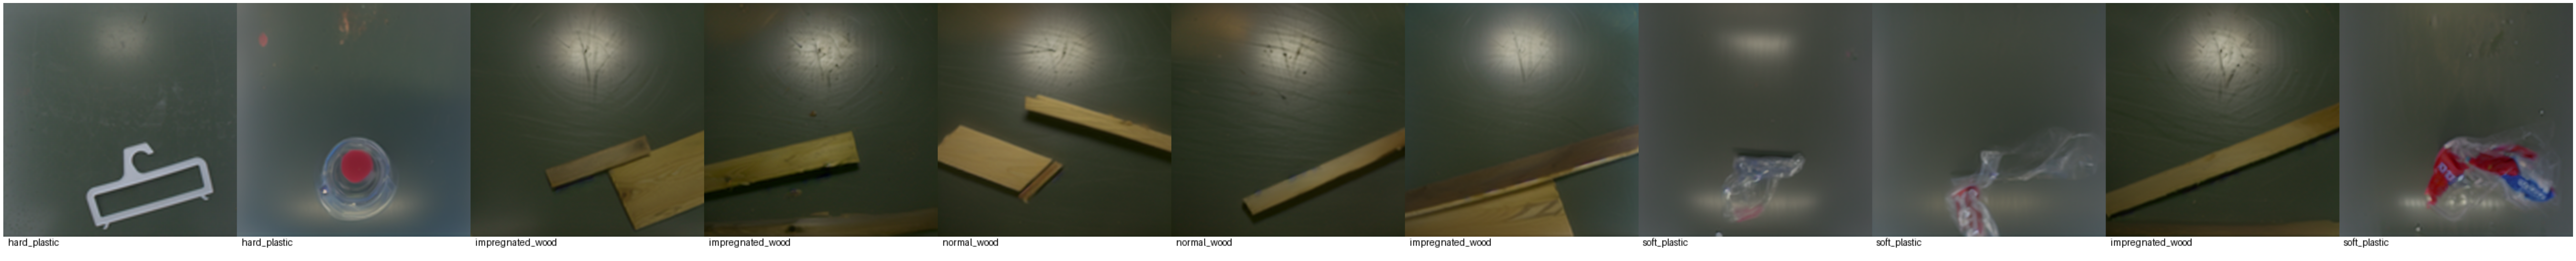

In [19]:
print(len(samples)) 
print(target_classes)
# resize the image to 128x128
samples = [transform(sample) for sample in samples]
image = samples[0]
print(type(image))
# convert image from PIL.Image.Image to numpy array
import numpy as np
image = np.array(image)
print(image.shape)

#plot the grid. The image is of class Image
import matplotlib.pyplot as plt
plt.figure(figsize=(100, 100))
plt.imshow(grid_to_show)
plt.axis('off')
plt.show()